# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [1]:
# If on colab, uncomment the following lines

! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [3]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,730,101,55,107,200,61,11,225,30,25,178,228,730,204,74,8,35,187,201
1,589,104,55,105,223,70,10,223,30,25,177,237,737,218,75,14,11,188,196
2,51,92,38,71,174,66,7,154,43,19,133,181,355,130,70,4,24,189,195
3,727,96,44,68,190,70,7,155,41,19,145,179,372,166,67,5,7,202,206
4,787,93,37,70,126,52,9,127,53,18,137,156,238,119,71,2,13,191,190
5,710,102,54,98,201,61,6,225,29,25,165,246,766,231,79,9,14,188,187
6,447,95,57,104,228,74,10,212,31,24,175,224,670,223,74,0,4,186,193
7,272,91,43,88,157,61,9,149,45,19,157,165,326,140,64,1,26,197,207
8,215,90,39,86,169,62,7,162,41,20,131,194,388,147,74,1,22,185,191
9,486,104,57,103,222,72,12,221,30,25,177,223,718,218,72,11,12,186,195


Methods `describe` and `info` deliver some useful information.

In [4]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,411.424408,93.874317,45.052823,82.622951,169.522769,61.748634,8.697632,169.812386,40.710383,20.666667,148.411658,189.593807,444.681239,175.617486,72.615665,6.520947,12.775956,188.870674,195.597450
std,243.629094,8.433329,6.215631,15.663253,33.593669,8.334182,5.121838,33.204566,7.829263,2.590691,14.580444,31.506760,176.197763,32.554437,7.937703,4.901029,9.244000,6.093526,7.358152
min,0.000000,73.000000,34.000000,42.000000,109.000000,47.000000,2.000000,114.000000,26.000000,17.000000,119.000000,131.000000,191.000000,112.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,198.000000,87.000000,40.000000,70.000000,142.000000,57.000000,7.000000,148.000000,33.000000,19.000000,137.000000,168.000000,321.000000,150.000000,67.000000,2.000000,5.000000,184.000000,190.000000
50%,415.000000,93.000000,45.000000,81.000000,168.000000,61.000000,8.000000,158.000000,42.000000,20.000000,146.000000,180.000000,371.000000,176.000000,71.000000,6.000000,11.000000,188.000000,197.000000
75%,619.000000,100.000000,50.000000,98.000000,197.000000,65.000000,10.000000,200.000000,46.000000,23.000000,160.000000,217.000000,600.000000,200.000000,76.000000,9.000000,20.000000,193.000000,201.000000
max,844.000000,116.000000,59.000000,110.000000,333.000000,138.000000,55.000000,261.000000,59.000000,28.000000,186.000000,320.000000,998.000000,264.000000,135.000000,22.000000,38.000000,204.000000,211.000000


In [5]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

In [6]:
### YOUR CODE HERE
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # we dont fit on test data because we dont want our model just remember the data adn overfit

# if we look into the data we can see that values vary a lot (1 - 845 is a huge gap). So we need to normilize our data by scaling it

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [7]:
### YOUR CODE HERE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score

log_reg =LogisticRegression(solver='saga', max_iter=500, tol=1e-3)
param_grid = {"C": [0.01, 0.1, 1, 10, 100, 1000]}
grid = GridSearchCV(estimator=log_reg, param_grid=param_grid, scoring='f1_macro', cv=3)
grid.fit(X_train_scaled, y_train)

print("Best params: ", grid.best_params_)

y_pred = grid.predict(X_test_scaled)
predicted_proba = grid.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best params:  {'C': 10}
Accuracy: 0.8013, F1: 0.7911


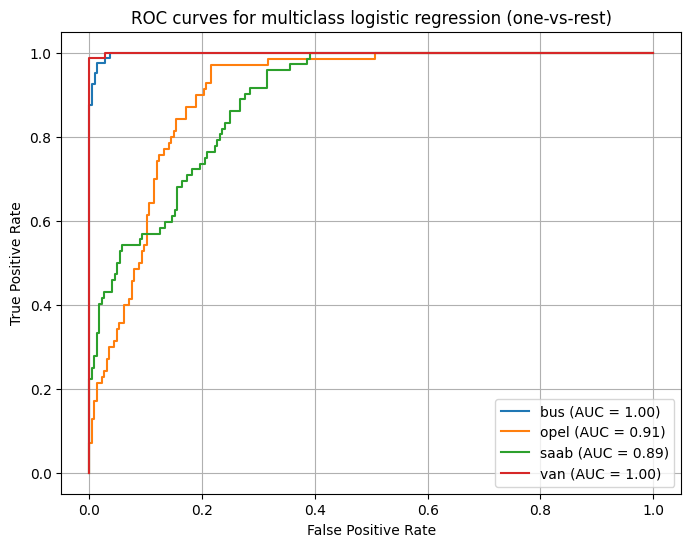

In [8]:
# couldnt use scikitplot because of compatibility issues so decides to do it by hand
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], predicted_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for multiclass logistic regression (one-vs-rest)')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# You might use this command to install scikit-plot. 
# Warning, if you a running locally, don't call pip from within jupyter, call it from terminal in the corresponding 
# virtual environment instead

# ! pip install scikit-plot

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot. 

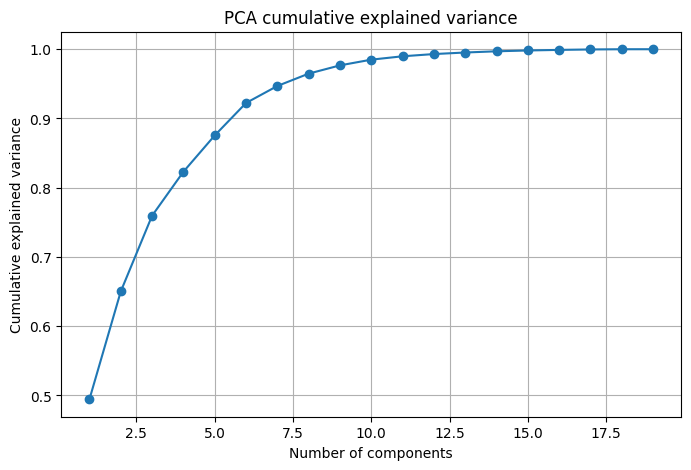

In [10]:
### YOUR CODE HERE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.grid(True)
plt.show()


#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

In [11]:
### YOUR CODE HERE
pca_10 = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#graph shows us that we can get more than95% information from 10 components

**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

In [12]:
### YOUR CODE HERE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg_pca = LogisticRegression(solver='saga', tol=1e-3)
param_grid_pca = {
    "C": [0.01, 0.1, 1, 10, 100, 1000]
}
grid_pca = GridSearchCV(estimator=log_reg_pca, param_grid=param_grid_pca, scoring='f1_macro', cv=3)
grid_pca.fit(X_train_pca, y_train)

print("Best parameters: ", grid_pca.best_params_)


c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\li

Best parameters:  {'C': 10}


c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\user\PycharmProjects\Abloberdiev_Shoislom_YMLS_Homeworks\.venv\Lib\site-packages\sklearn\li

In [13]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_pca = grid_pca.best_estimator_.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred)
f1_pca = f1_score(y_test, y_pred, average='macro')

print(acc_pca, f1_pca)

0.8013468013468014 0.7910547210198278


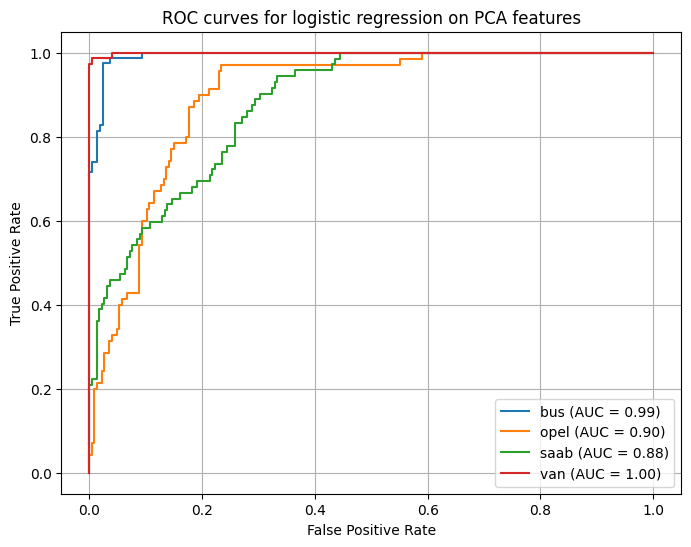

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba_pca = grid_pca.best_estimator_.predict_proba(X_test_pca)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_pca[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for logistic regression on PCA features')
plt.legend()
plt.grid(True)
plt.show()


#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [15]:
from sklearn.tree import DecisionTreeClassifier
# YOUR CODE HERE

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score


tree_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state=1))
])

param_grid_tree = {
    'tree__max_depth': [2, 4, 6, 8, 10, 12, 15]
}

grid_tree = GridSearchCV(estimator=tree_pipeline, param_grid=param_grid_tree, scoring='f1_macro', cv=3)

grid_tree.fit(X_train, y_train)
print("Best parameters: ", grid_tree.best_params_)


Best parameters:  {'tree__max_depth': 8}


In [16]:
y_pred_tree =  grid_tree.best_estimator_.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree, average='macro')

print("Accuracy (tree, no PCA):", acc_tree)
print("F1 (macro, tree, no PCA):", f1_tree)


Accuracy (tree, no PCA): 0.7070707070707071
F1 (macro, tree, no PCA): 0.6947359102818582


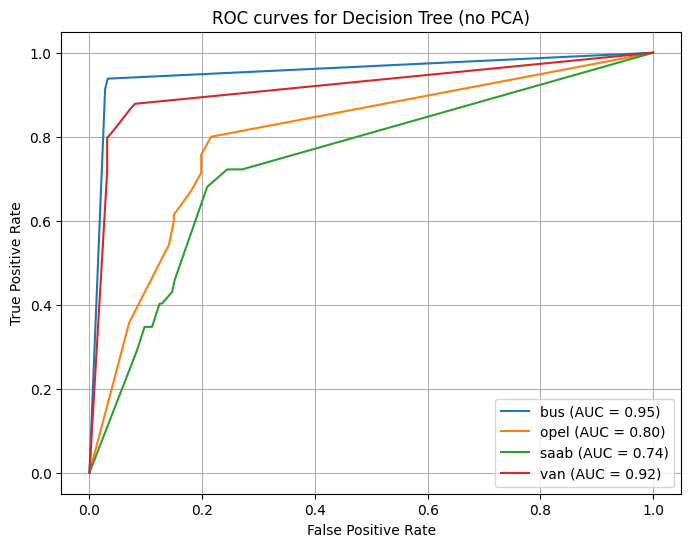

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba_tree = grid_tree.best_estimator_.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_tree[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for Decision Tree (no PCA)')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
tree_pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('tree', DecisionTreeClassifier(random_state=1))
])

param_grid_tree_pca = {
    'tree__max_depth': [2, 4, 6, 8, 10, 12, 15]
}

grid_tree_pca = GridSearchCV(estimator=tree_pca_pipe, param_grid=param_grid_tree_pca, scoring='f1_macro', cv=3)

grid_tree_pca.fit(X_train, y_train)
print("Best parameters: ", grid_tree_pca.best_params_)

Best parameters:  {'tree__max_depth': 8}


In [19]:
y_pred_tree =  grid_tree_pca.best_estimator_.predict(X_test)

acc_tree_pca = accuracy_score(y_test, y_pred_tree)
f1_tree_pca = f1_score(y_test, y_pred_tree, average='macro')

print("Accuracy (tree, with PCA):", acc_tree_pca)
print("F1 (macro, tree, with PCA):", f1_tree_pca)


Accuracy (tree, with PCA): 0.6430976430976431
F1 (macro, tree, with PCA): 0.6402004510935515


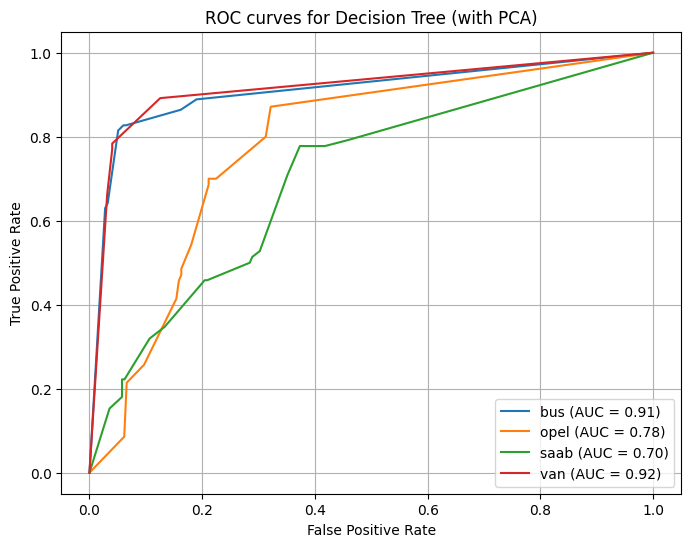

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba_tree = grid_tree_pca.best_estimator_.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_tree[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for Decision Tree (with PCA)')
plt.legend()
plt.grid(True)
plt.show()


#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble? 

In [43]:
# YOUR CODE HERE
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


N_min = 2
N_max = 100
step = 5
ensemble_sizes = list(range(N_min, N_max+1, step))
param_grid_tree = {
    "max_depth": [8]
}

dt = DecisionTreeClassifier(random_state=1)
grid_tree = GridSearchCV(estimator=dt, param_grid=param_grid_tree, scoring='f1_macro', cv=3)
grid_tree.fit(X_train_scaled, y_train)

base_log_reg = LogisticRegression(solver='saga', max_iter=500, tol=1e-3, random_state=1, C=10)
base_tree = DecisionTreeClassifier(random_state=1, **grid_tree.best_params_)

def evaluate_ensemble(base_estimator, X_train, y_train, X_test, y_test, ensemble_sizes, random_state=1):
    accuracys = []
    f1s = []

    for n in ensemble_sizes:
        bag = BaggingClassifier(estimator=base_estimator, n_estimators=n, random_state=random_state)
        bag.fit(X_train, y_train)

        y_pred = bag.predict(X_test)

        accuracys.append(accuracy_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred, average='macro'))

    return accuracys, f1s

log_accs, log_f1s = evaluate_ensemble(base_log_reg, X_train_scaled, y_train, X_test_scaled, y_test, ensemble_sizes)
tree_accs, tree_f1s = evaluate_ensemble(base_tree, X_train_scaled, y_train, X_test_scaled, y_test, ensemble_sizes)

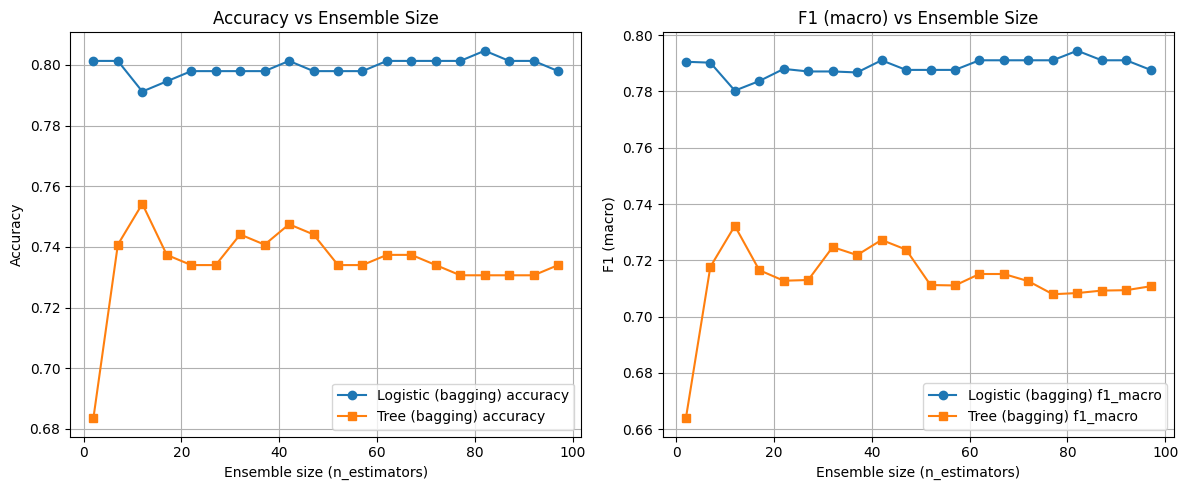

Best logistic ensemble size (by F1): 82 F1= 0.7944552763263697 Acc= 0.8047138047138047
Best tree ensemble size (by F1): 12 F1= 0.732245897068257 Acc= 0.7542087542087542


In [44]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ensemble_sizes, log_accs, marker='o', label='Logistic (bagging) accuracy')
plt.plot(ensemble_sizes, tree_accs, marker='s', label='Tree (bagging) accuracy')
plt.xlabel('Ensemble size (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Ensemble Size')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(ensemble_sizes, log_f1s, marker='o', label='Logistic (bagging) f1_macro')
plt.plot(ensemble_sizes, tree_f1s, marker='s', label='Tree (bagging) f1_macro')
plt.xlabel('Ensemble size (n_estimators)')
plt.ylabel('F1 (macro)')
plt.title('F1 (macro) vs Ensemble Size')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

best_log_idx = int(np.argmax(log_f1s))
best_tree_idx = int(np.argmax(tree_f1s))
print("Best logistic ensemble size (by F1):", ensemble_sizes[best_log_idx], "F1=", log_f1s[best_log_idx], "Acc=", log_accs[best_log_idx])
print("Best tree ensemble size (by F1):", ensemble_sizes[best_tree_idx], "F1=", tree_f1s[best_tree_idx], "Acc=", tree_accs[best_tree_idx])


logreg: optimal at 82 estimators
des_trees: optimal at 12 estimators

As we can see max_depth=8 seems not optimal:(

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt 
import numpy as np 

N_min = 2
N_max = 100
step = 5
forest_sizes = list(range(N_min, N_max+1, step))

rf_accs = []
rf_f1s = []

for n in forest_sizes:
    rf = RandomForestClassifier(n_estimators=n, random_state=1, max_depth=grid_tree.best_params_['max_depth'])
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)
    rf_accs.append(accuracy_score(y_test, y_pred))
    rf_f1s.append(f1_score(y_test, y_pred, average='macro'))

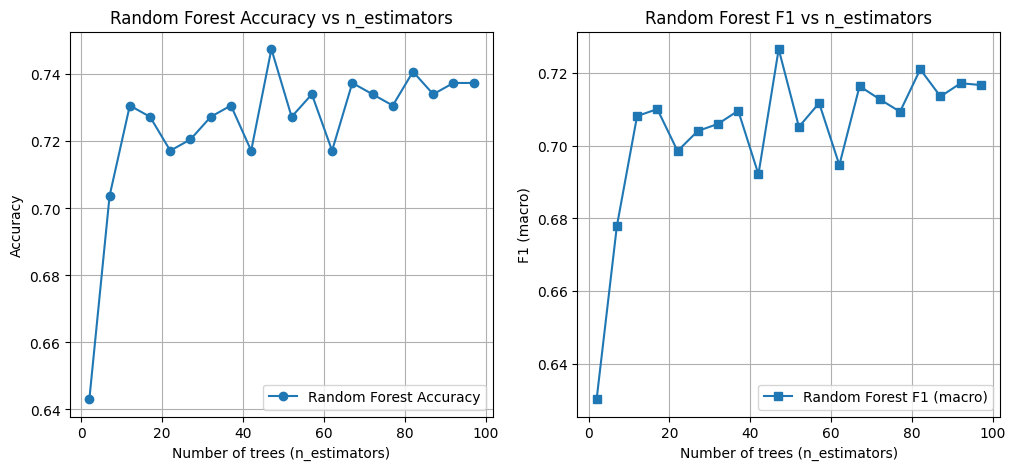

Best Random Forest n_estimators (by F1): 47 F1= 0.7265407482381422 Acc= 0.7474747474747475


In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(forest_sizes, rf_accs, marker='o', label='Random Forest Accuracy')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs n_estimators')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(forest_sizes, rf_f1s, marker='s', label='Random Forest F1 (macro)')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('F1 (macro)')
plt.title('Random Forest F1 vs n_estimators')
plt.grid(True)
plt.legend()

plt.show()

best_rf_idx = int(np.argmax(rf_f1s))
print("Best Random Forest n_estimators (by F1):", forest_sizes[best_rf_idx], "F1=", rf_f1s[best_rf_idx], "Acc=", rf_accs[best_rf_idx])


optimal trees: 47
slightly worse that logistic and tree baggings

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it? 

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score


n_parts = 10
part_size = X_train_scaled.shape[0] // n_parts
indxs = np.arange(X_train_scaled.shape[0])

def learning_curve_model(model_class, model_params, parts, X_train, y_train, X_test, y_test):
    acc_list = []
    f1_list = []
    sizes = []
    
    for i in range(1, len(parts)+1):
        train_idx = np.concatenate(parts[:i])
        X_part = X_train[train_idx]
        y_part = y_train[train_idx]
        
        model = model_class(**model_params)
        model.fit(X_part, y_part)
        y_pred = model.predict(X_test)
        
        acc_list.append(accuracy_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred, average='macro'))
        sizes.append(len(train_idx))
        
    return sizes, acc_list, f1_list

log_params = {
    "C": 10,
    "solver": "saga",
    "tol": 1e-3,
    "max_iter": 500,
    "random_state": 1
}
log_sizes, log_accs, log_f1s = learning_curve_model(LogisticRegression, log_params, parts, X_train_scaled, y_train, X_test_scaled, y_test)

tree_params = {
    "random_state": 1,
    **grid_tree.best_params_
}
tree_sizes, tree_accs, tree_f1s = learning_curve_model(DecisionTreeClassifier, tree_params, parts, X_train_scaled, y_train, X_test_scaled, y_test)

rf_params = {
    "n_estimators": forest_sizes[best_rf_idx],
    "random_state": 1,
    **grid_tree.best_params_
}
rf_sizes, rf_accs, rf_f1s = learning_curve_model(RandomForestClassifier, rf_params, parts, X_train_scaled, y_train, X_test_scaled, y_test)


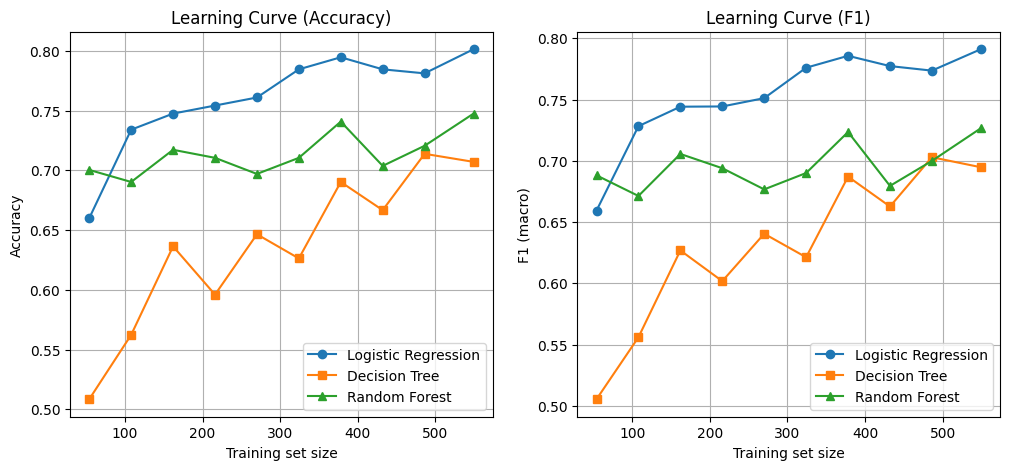

In [49]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(log_sizes, log_accs, marker='o', label='Logistic Regression')
plt.plot(tree_sizes, tree_accs, marker='s', label='Decision Tree')
plt.plot(rf_sizes, rf_accs, marker='^', label='Random Forest')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Accuracy)')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(log_sizes, log_f1s, marker='o', label='Logistic Regression')
plt.plot(tree_sizes, tree_f1s, marker='s', label='Decision Tree')
plt.plot(rf_sizes, rf_f1s, marker='^', label='Random Forest')
plt.xlabel('Training set size')
plt.ylabel('F1 (macro)')
plt.title('Learning Curve (F1)')
plt.grid(True)
plt.legend()

plt.show()


logreg - best performer - still improving with more data
decision tree - worst - overfitting
random dorest - doesnt gain too much from more data

likely dataset has some linear patterns

#### 2.9. Boosting
Your goal is to build a boosting ensemble using xgboost, CatBoost or lightgbm package.
Please, do not use the sklearn API for these models.

Find optimal number of decision trees in the boosting ensembe using grid search or other methods.
Please, explain your answer.

Learning rate set to 0.5
0:	learn: 1.0325029	total: 3.78ms	remaining: 34ms
1:	learn: 0.8702360	total: 7.21ms	remaining: 28.8ms
2:	learn: 0.8113833	total: 10.7ms	remaining: 25ms
3:	learn: 0.7357121	total: 14.8ms	remaining: 22.2ms
4:	learn: 0.6888553	total: 19.4ms	remaining: 19.4ms
5:	learn: 0.6283197	total: 22.7ms	remaining: 15.1ms
6:	learn: 0.6054504	total: 26ms	remaining: 11.1ms
7:	learn: 0.5690298	total: 30.9ms	remaining: 7.72ms
8:	learn: 0.5455005	total: 34.5ms	remaining: 3.83ms
9:	learn: 0.5231562	total: 38ms	remaining: 0us
Learning rate set to 0.5
0:	learn: 1.0325029	total: 4.15ms	remaining: 78.9ms
1:	learn: 0.8702360	total: 7.9ms	remaining: 71.1ms
2:	learn: 0.8113833	total: 14.1ms	remaining: 80ms
3:	learn: 0.7357121	total: 18.2ms	remaining: 72.7ms
4:	learn: 0.6888553	total: 21.9ms	remaining: 65.6ms
5:	learn: 0.6283197	total: 27.7ms	remaining: 64.7ms
6:	learn: 0.6054504	total: 31.9ms	remaining: 59.3ms
7:	learn: 0.5690298	total: 35.9ms	remaining: 53.9ms
8:	learn: 0.5455005	total: 4

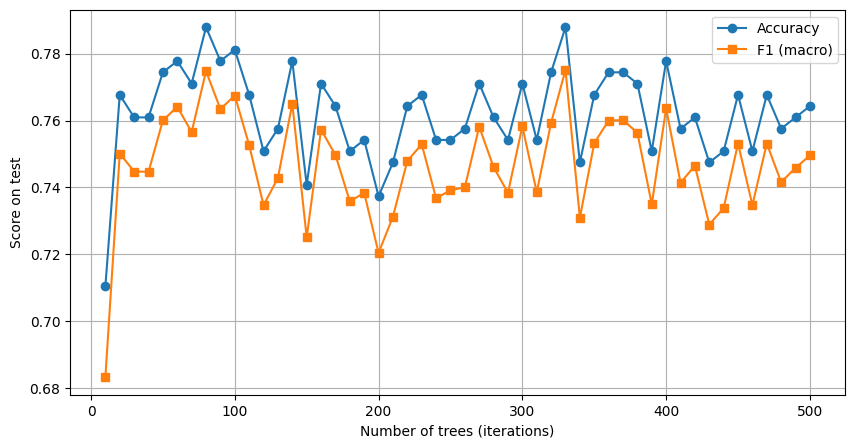

Best iterations (by F1): 330
Best F1: 0.7751, Accuracy: 0.7879


In [59]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

iter_list = list(range(10, 501, 10))
acc_list = []
f1_list = []


for it in iter_list:
    model = CatBoostClassifier(iterations=it, random_seed=1)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)


    acc_list.append(accuracy_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred, average='macro'))

plt.figure(figsize=(10,5))
plt.plot(iter_list, acc_list, marker='o', label='Accuracy')
plt.plot(iter_list, f1_list, marker='s', label='F1 (macro)')
plt.xlabel('Number of trees (iterations)')
plt.ylabel('Score on test')
# plt.title(f'CatBoost: iterations vs Accuracy/F1 (lr={learning_rate}, depth={depth})')
plt.grid(True)
plt.legend()
plt.show()

best_idx = int(np.argmax(f1_list))
best_iterations = iter_list[best_idx]
print("Best iterations (by F1):", best_iterations)
print(f"Best F1: {f1_list[best_idx]:.4f}, Accuracy: {acc_list[best_idx]:.4f}")
